#  [Mini-Project 1: London Air Quality Analysis]: NB3- Data-Analysis

In [2]:
import pandas as pd
import numpy as np

## Section 1: CSV loaded

**Reload CSV and convert back to datetime**

In [3]:
df = pd.read_csv("data/london_pollution_processed.csv")
df["dt"] = pd.to_datetime(df["dt"], utc=True) 

print("Data loaded")
print(f" TEST {df.head()}")

Data loaded
 TEST                          dt                             location  aqi      co  \
0 2022-03-31 23:00:00+00:00  Equestrian_Statue_of_King_Charles_I  1.0  257.02   
1 2022-04-01 00:00:00+00:00  Equestrian_Statue_of_King_Charles_I  1.0  257.02   
2 2022-04-01 01:00:00+00:00  Equestrian_Statue_of_King_Charles_I  1.0  257.02   
3 2022-04-01 02:00:00+00:00  Equestrian_Statue_of_King_Charles_I  2.0  260.35   
4 2022-04-01 03:00:00+00:00  Equestrian_Statue_of_King_Charles_I  2.0  263.69   

    no   no2     o3  pm2_5  pm10   so2   nh3  dayofweek  is_weekend  year  \
0  0.0  6.34  72.96   0.92  1.94  2.50  3.55          3       False  2022   
1  0.0  6.34  75.10   1.22  2.29  2.71  3.80          4       False  2022   
2  0.0  6.25  78.68   1.68  2.81  2.95  3.36          4       False  2022   
3  0.0  5.83  80.82   1.81  2.99  2.92  2.79          4       False  2022   
4  0.0  5.57  80.82   1.80  3.01  2.83  2.25          4       False  2022   

   month  day weekday_name  
0  

<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #000000ff; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Info + my understanding of cell above**
1. Advanced features: NA
2. My understanding: Took this from the slides, but removed unit='s' because I'm already in a datetime compatible format.      
Then just printing to see if it looks alright.       
Initially didn't know that the dt column looses the datetime type and becomes a string when I reload the CSV, claude helped me realize that bit.

</div>

## Section 2: Vectorized analysis performed

**Aggregate Pollution Data by Location, Year, Month, and Weekend Status**

In [4]:
summary = (
    df
    .groupby(['location', 'year', 'month', 'is_weekend'])[['pm2_5', 'pm10', 'so2', 'no2', 'o3', 'co']]
    .mean()
    .reset_index()
    .round(2)
)

print("Grouped by location, year, month, and weekday/weekend")
print(summary.head(15))

Grouped by location, year, month, and weekday/weekend
                               location  year  month  is_weekend  pm2_5  \
0   Equestrian_Statue_of_King_Charles_I  2022      3       False   0.92   
1   Equestrian_Statue_of_King_Charles_I  2022      4       False   7.03   
2   Equestrian_Statue_of_King_Charles_I  2022      4        True   9.23   
3   Equestrian_Statue_of_King_Charles_I  2022      5       False   5.13   
4   Equestrian_Statue_of_King_Charles_I  2022      5        True   5.15   
5   Equestrian_Statue_of_King_Charles_I  2022      6       False   6.55   
6   Equestrian_Statue_of_King_Charles_I  2022      6        True   3.79   
7   Equestrian_Statue_of_King_Charles_I  2022      7       False   4.43   
8   Equestrian_Statue_of_King_Charles_I  2022      7        True   3.98   
9   Equestrian_Statue_of_King_Charles_I  2022      8       False   5.51   
10  Equestrian_Statue_of_King_Charles_I  2022      8        True   6.85   
11  Equestrian_Statue_of_King_Charles_I  2022 

<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #000000ff; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Info + my understanding of cell above**
1. Advanced features: **round** I dont know about advanced, but data was long floats, so I assumed there was a round function and rounded by 2 decimal places
2. My understanding: **.groupby(['location', 'year', 'month', 'is_weekend'])[['pm2_5', 'pm10', 'so2', 'no2', 'o3', 'co']]**: Splits data into groups by location, year, month, and whether it is a weekend or not, then selects only those 6 pollutant columns to aggregate     
**.reset_index()** was just pulled from the slides, but claude helped me understand that .reset_index makes the four data groups from .groupby columns, without it they would be index labels. I'm guessing having them as columns simplified my analysis in seaborn visualizations.

</div>

<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #3D9444; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Further reflections on cell above**
- I chose to focus on pm2_5, pm10, so2, no2, o3, & co because these are the main pollutants to directly effect respiritory health
- Sources for this decision can be found in README.md

</div>

## Section 3: Seaborn visualisations

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.makedirs('figures', exist_ok=True)

print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print("Libraries loaded successfully!")

matplotlib version: 3.10.3
seaborn version: 0.13.2
Libraries loaded successfully!


<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #000000ff; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Info + my understanding of cell above**
1. Advanced features: NA
2. My understanding: **os.makedirs('figures', exist_ok=True)**: In pulling most of this from Lab5, I initially missed this and was getting errors because I was trying to save the file to a nonexistant folder. Now I understand that this code creates a folder, and exist_ok=True means if the folder already exists, don't create one. 

</div>

**Insight 1**

    is_weekend pollutant      level
0        False        no   4.426484
1         True        no   3.894208
2        False       no2  16.104162
3         True       no2  13.508846
4        False        o3  55.887593
5         True        o3  58.051230
6        False       so2   6.224936
7         True       so2   5.266191
8        False     pm2_5   6.261696
9         True     pm2_5   6.227305
10       False      pm10   7.803027
11        True      pm10   8.197261
12       False       nh3   0.809145
13        True       nh3   0.871555
14       False        co  22.019686
15        True        co  21.864972


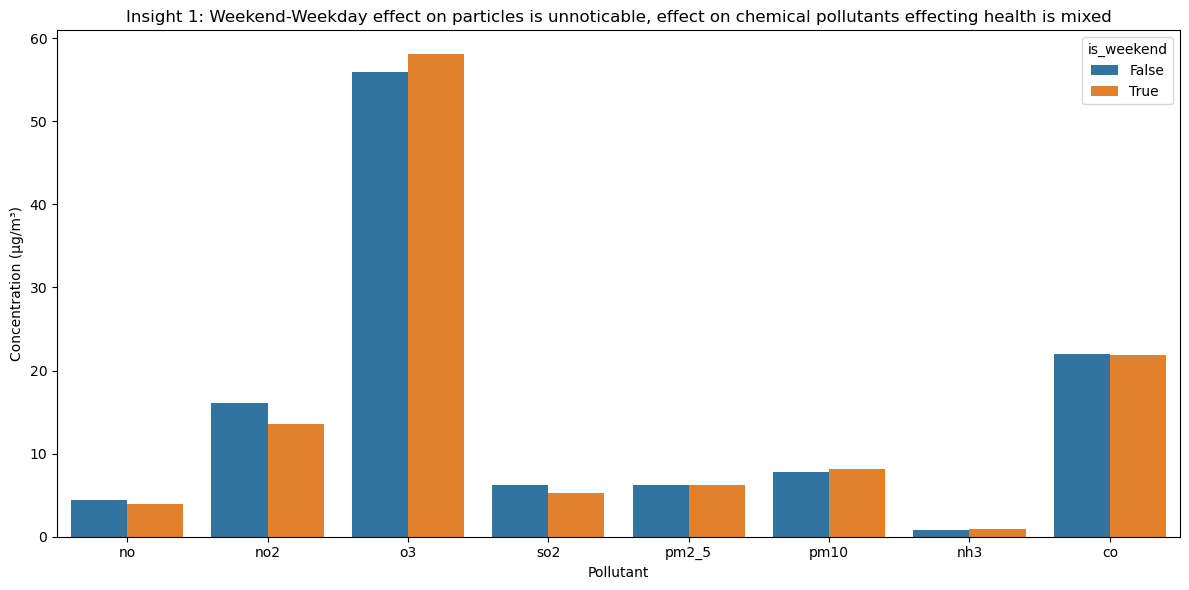

In [28]:
plot_df = (
    df.groupby('is_weekend')[['no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']]
    .mean()
    .reset_index()
)

plot_df['co'] = df.groupby('is_weekend')['co'].mean() / 10

#.melt() from pandas
plot_df_long = plot_df.melt(id_vars='is_weekend', var_name='pollutant', value_name='level')
print(plot_df_long)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df_long, x='pollutant', y='level', hue='is_weekend')
plt.title("Insight 1: Weekend-Weekday effect on particles is unnoticable, effect on chemical pollutants effecting health is mixed")
plt.xlabel("Pollutant")
plt.ylabel("Concentration (μg/m³)")
plt.tight_layout()
plt.savefig('figures/insight1.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #000000ff; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Info + my understanding of cell above**
1. Advanced features: **.melt() for reshaping data**: converts wide format were columns = pollutants (like it was printed in section 2), to the long format seen here (from print(plot_df_long)). This allows me to have an x with multiple pollutants (as there are now multiple pollutants to a column).     
This also lets me use **hue='is_weekend'** to have weekday and weekend bars as a different color. I might understand it wrong, but just add it in the sns.xplot command, after x and y are defined I'm guessing.
2. My understanding: 
**plot_df = (     
    df.groupby('is_weekend')[['no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']]    
    .mean()    
    .reset_index()    
)**: grouping and averaging data so I have one value per pollutant per weekend or weekday, instead of how-many-so hourly readings.

**plot_df['co'] = df.groupby('is_weekend')['co'].mean() / 10**: Adding co later so I can divide it by 10, as it was originally too large and distorting the graph

</div>

**Insight 2**

                               location  is_weekend pollutant      level
0   Equestrian_Statue_of_King_Charles_I       False        no   6.098057
1   Equestrian_Statue_of_King_Charles_I        True        no   5.641253
2             Queen_Elizabeth_II_Bridge       False        no   2.754910
3             Queen_Elizabeth_II_Bridge        True        no   2.147162
4   Equestrian_Statue_of_King_Charles_I       False       no2  18.204098
5   Equestrian_Statue_of_King_Charles_I        True       no2  15.652580
6             Queen_Elizabeth_II_Bridge       False       no2  14.004225
7             Queen_Elizabeth_II_Bridge        True       no2  11.365112
8   Equestrian_Statue_of_King_Charles_I       False        o3  53.727979
9   Equestrian_Statue_of_King_Charles_I        True        o3  55.979936
10            Queen_Elizabeth_II_Bridge       False        o3  58.047208
11            Queen_Elizabeth_II_Bridge        True        o3  60.122524
12  Equestrian_Statue_of_King_Charles_I       False

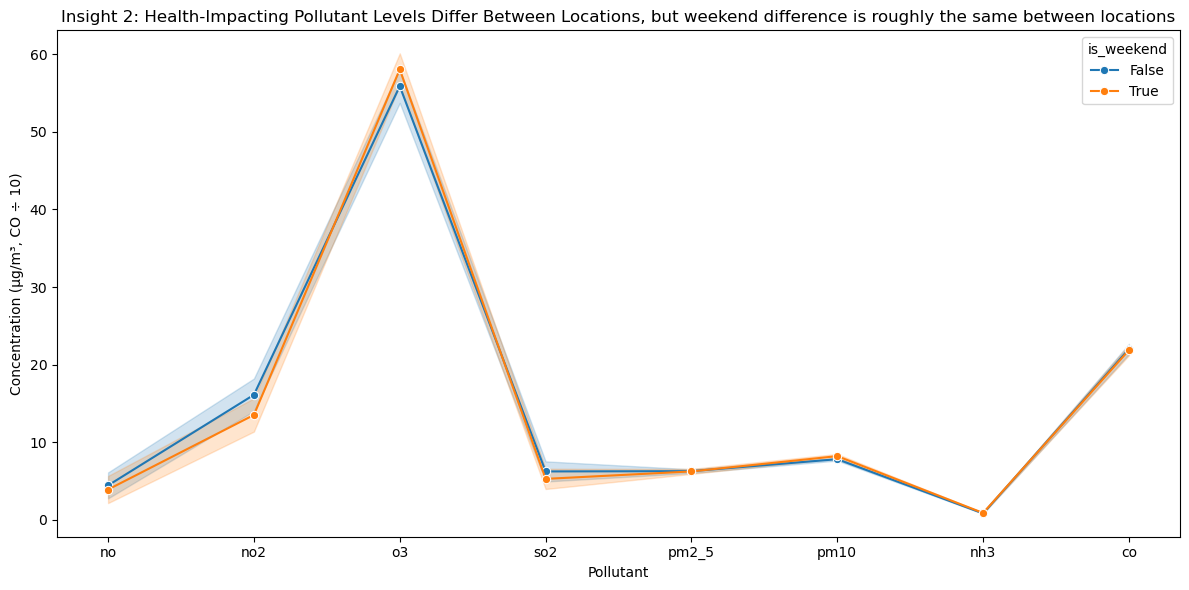

In [33]:
plot_df = (
    df.groupby(['location', 'is_weekend'])[['no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']]
    .mean()
    .reset_index()
)

co_mean = df.groupby(['location', 'is_weekend'])['co'].mean().reset_index()
plot_df['co'] = co_mean['co'] / 10

plot_df_long = plot_df.melt(id_vars=['location', 'is_weekend'], var_name='pollutant', value_name='level')
print(plot_df_long)

plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df_long, x='pollutant', y='level', hue='is_weekend', marker='o')
plt.title("Insight 2: Health-Impacting Pollutant Levels Differ Between Locations, but weekend difference is roughly the same between locations")
plt.xlabel("Pollutant")
plt.ylabel("Concentration (μg/m³, CO ÷ 10)")
plt.tight_layout()
plt.savefig('figures/insight2.png', dpi=300, bbox_inches='tight')
plt.show()

<div style="font-family: system-ui; padding: 10px 10px 10px 10px; background-color: #FFFFFF; border-left: 8px solid #000000ff; border-radius: 5px; box-shadow: 0 4px 12px rgba(0, 0, 0, 0.1); max-width: 600px; color: #212121; font-size: 14px;">

**Info + my understanding of cell above**
1. Advanced features: **marker**: adds circular dots at each data point in a line plot. Can be o for circles, s for squares, and some more.
2. My understanding: Same as Insight 1, except grouping by location and is_weekend 
**co_mean = df.groupby(['location', 'is_weekend'])['co'].mean().reset_index()
plot_df['co'] = co_mean['co'] / 10**: adding co was more difficult here, the only difference is that plot_df was grouped by 2 instead of 1, so im guessting thats it, and is why I added .reset_index() to the co groupby.

</div>